In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler


In [2]:
#Load the dataset
data=pd.read_csv("CarPrice_Assignment (4).csv")
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
#Data Processing
#Dropping unnecessary columns and handling categorical variables
data=data.drop(['CarName','car_ID'], axis=1)
data=pd.get_dummies(data,drop_first=True)               

In [4]:
#Splitting the data into features and target variables
x=data.drop('price',axis=1)
y=data['price']

In [5]:
#Standardizing the data
scaler = StandardScaler()
x=scaler.fit_transform(x)
y=scaler.fit_transform(np.array(y).reshape(-1,1))




In [6]:
#Splitting the dataset into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
#Creating the SGD Regressor model
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)


In [8]:
#Fitting the model on the training data
sgd_model.fit(x_train,y_train)

C:\Users\balasurya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [9]:
#Making predictions
y_pred=sgd_model.predict(x_test)

In [10]:
#Evaluating model performance
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [11]:
#Print evaluation metrics
print('Name:HARI PRASATH M')
print('Reg. No: 212225100015')
print("Mean Squared Error:",mse)
print("R-squared Score:",r2)
print("Mean Absolute Error:",mae)

Name:HARI PRASATH M
Reg. No: 212225100015
Mean Squared Error: 0.21174834147044516
R-squared Score: 0.8296485367654916
Mean Absolute Error: 0.3130562826115946


In [12]:
#Print model coefficients
print("\nModel Coefficients:")
print("Coefficients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)



Model Coefficients:
Coefficients: [ 3.35927418e-02  1.05439548e-01  1.37915806e-02  1.71025821e-01
  1.56974827e-02  1.64111586e-01  2.80279810e-01 -1.84479653e-02
 -8.40354928e-02  5.01921894e-03  1.03695825e-01  3.94150321e-02
 -4.20847675e-02 -5.20872595e-02 -2.23129868e-02  1.79138428e-02
  2.25063070e-02 -1.73537679e-02 -8.74062357e-02 -1.26101746e-02
 -9.26894902e-02 -3.01467787e-02  5.87629413e-02  2.09108989e-01
  1.46855334e-02 -9.83111395e-02  7.76328779e-02 -1.43385738e-02
 -2.64476385e-04  9.36407082e-03 -3.44365981e-02 -1.40991663e-01
 -6.70531161e-02  8.15119566e-04 -2.46392098e-02  9.36407082e-03
 -7.56457641e-04 -1.51498639e-02  2.23129868e-02 -1.87300973e-02
 -3.44901705e-02 -4.09970279e-02 -1.66443118e-02]
Intercept: [-0.01164662]


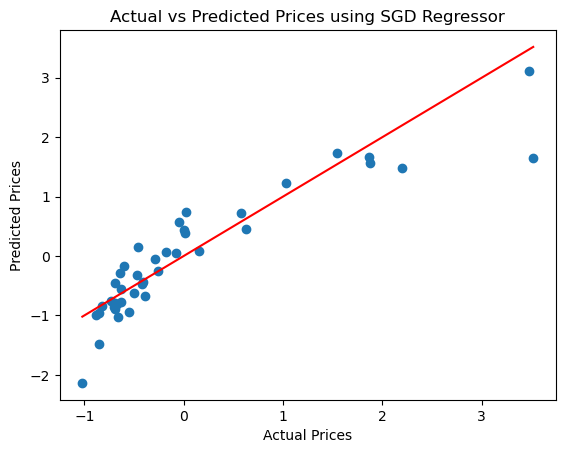

In [13]:
#Visualizing actual vs predicted prices
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red') #Perfect prediction line
plt.show()